<a href="https://colab.research.google.com/github/rehmanamna910-ux/Sentiment-Analysis-using-Agentic-AI/blob/main/SAAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
import numpy as np
from sklearn.metrics import accuracy_score

# Step 2: Load the dataset
# Load the data from the CSV file. Please update the file path if needed.
data = pd.read_csv("/content/drive/MyDrive/sentiment_responses.csv", encoding='latin1')
# Display the first few rows to check the data structure. Make sure 'answer_text' and 'sentiment' columns exist.
print(data.head())

# Step 3: Prepare the data for training
# Convert sentiment labels (like NEGATIVE, NEUTRAL, POSITIVE) into numbers (0, 1, 2).
sentiment_map = {"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}
data['label'] = data['sentiment'].map(sentiment_map)
# Remove any rows where the sentiment label could not be mapped to a number.
data.dropna(subset=['label'], inplace=True)
# Ensure the labels are stored as whole numbers.
data['label'] = data['label'].astype(int)

# Step 4: Split the data into training and testing sets
# Divide the dataset into two parts: one for training the model and one for testing its performance.
# 80% of the data is for training, and 20% is for testing.
train_texts, test_texts, train_labels, test_labels = train_test_split(
    data['answer_text'], data['label'], test_size=0.2, random_state=42
)

# Step 5: Load the pre-trained model and tokenizer
# Specify the name of the pre-trained sentiment model to use.
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
# Load the tokenizer, which converts text into a format the model understands.
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Load the pre-trained model for sequence classification, setting it up for 3 possible sentiment labels.
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Configure device for model (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Step 6: Configure the model
# Tell the model that it's performing a single-label classification task.
model.config.problem_type = "single_label_classification"

# Step 7: Tokenize the text data
# Convert the training and testing texts into numerical inputs (tokens) that the model can process.
# 'truncation=True' cuts off long texts, and 'padding=True' makes all texts the same length.
train_encodings = tokenizer(train_texts.astype(str).tolist(), truncation=True, padding=True)
test_encodings = tokenizer(test_texts.astype(str).tolist(), truncation=True, padding=True)

# Step 8: Create a custom Dataset for PyTorch
# Define a custom class to hold the tokenized text and their corresponding labels.
class SentimentDataset(torch.utils.data.Dataset):
    # Initialize the dataset with encoded texts and labels.
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    # Return the total number of items in the dataset.
    def __len__(self):
        return len(self.labels)

    # Get a single item (text and label) from the dataset by its index.
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

# Create instances of the custom dataset for training and testing.
train_dataset = SentimentDataset(train_encodings, train_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

# Step 9: Set up training arguments
# Configure settings for the training process, such as batch size, number of training cycles (epochs), and saving strategy.
training_args = TrainingArguments(
    output_dir="./results", # Folder to save model outputs
    per_device_train_batch_size=8, # Number of samples per training batch
    per_device_eval_batch_size=8, # Number of samples per evaluation batch
    num_train_epochs=2, # Number of times to run through the entire training dataset
    eval_strategy="epoch", # Evaluate the model after each epoch
    logging_steps=10, # Log training progress every 10 steps
    save_strategy="epoch", # Save the model after each epoch
    load_best_model_at_end=True # Load the best performing model after training is complete
)

# Step 10: Define evaluation metrics
# Create a function to calculate accuracy for evaluating the model's performance.
def compute_metrics(eval_pred):
    # Get the model's predicted scores (logits) and the true labels.
    logits, labels = eval_pred
    # Convert predicted scores into class predictions (e.g., 0, 1, or 2).
    predictions = np.argmax(logits, axis=-1)
    # Return the accuracy score by comparing predictions to true labels.
    return {"accuracy": accuracy_score(labels, predictions)}

# Step 11: Initialize the Hugging Face Trainer
# Set up the Trainer with the model, training arguments, datasets, and metrics function.
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Step 12: Train the model
# Start the training process for the sentiment analysis model.
trainer.train()

# Step 13: Evaluate the trained model
# Evaluate the model's performance on the test dataset.
results = trainer.evaluate()
# Print the evaluation results.
print(results)

   respondent_id question_id             answer_text sentiment
0            1.0          Q3  Excited or comfortable  POSITIVE
1            1.0          Q5          Very concerned  NEGATIVE
2            1.0          Q6                   Agree  POSITIVE
3            1.0          Q7      I dont trust them  NEGATIVE
4            1.0          Q8             Comfortable  POSITIVE


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.000600,0.056916,0.992481
2,0.000500,0.053347,0.988722


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.05334685370326042, 'eval_accuracy': 0.9887218045112782, 'eval_runtime': 13.3901, 'eval_samples_per_second': 19.865, 'eval_steps_per_second': 2.539, 'epoch': 2.0}


In [ ]:
# Step 14: Perform real-time sentiment predictions
# Create a mapping to convert numerical predictions back to sentiment labels (NEGATIVE, NEUTRAL, POSITIVE).
inv_map = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}

# Ask the user to input text for sentiment prediction.
user_input = input("Enter text for sentiment prediction: ")

# Tokenize the user's input text.
pred_encodings = tokenizer(user_input, truncation=True, padding=True, return_tensors="pt")
# Move input tensors to the same device as the model
pred_encodings = {k: v.to(device) for k, v in pred_encodings.items()}

# Get the model's predictions for the input text.
outputs = model(**pred_encodings)
# Determine the sentiment class with the highest probability.
preds = torch.argmax(outputs.logits, dim=1)
# Convert the numerical prediction back to a sentiment label.
pred_text = inv_map[preds.item()]
# Print the predicted sentiment.
print(f"Predicted sentiment: {pred_text}")

Enter text for sentiment prediction: i don't like AI
Predicted sentiment: NEGATIVE


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


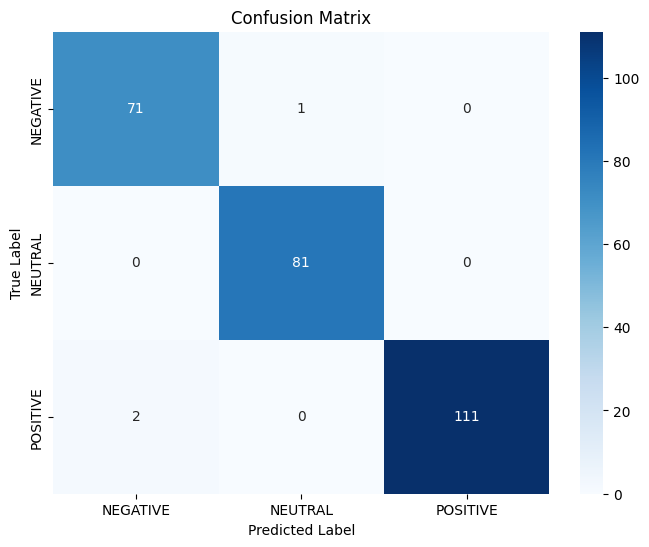

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Step 15: Get model predictions on the test set
# Use the trained model to make predictions on the unseen test data.
predictions = trainer.predict(test_dataset)

# Step 16: Extract predicted labels
# Convert the model's output (logits) into specific predicted sentiment labels.
preds = np.argmax(predictions.predictions, axis=-1)

# Step 17: Get true labels
# Retrieve the actual sentiment labels from the test dataset.
true_labels = test_dataset.labels

# Step 18: Calculate the confusion matrix
# Compute the confusion matrix, which shows how many predictions were correct versus incorrect for each sentiment category.
cm = confusion_matrix(true_labels, preds)

# Step 19: Define class names
# Get the names of the sentiment classes (e.g., NEGATIVE, NEUTRAL, POSITIVE) for clarity in the plot.
class_names = list(sentiment_map.keys())

# Step 20: Visualize the confusion matrix
# Create a heatmap to visually represent the confusion matrix.
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# Label the axes and add a title for better understanding.
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
# Display the plot.
plt.show()